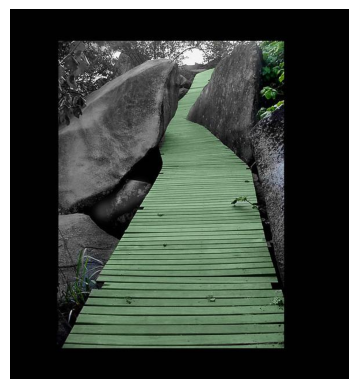

In [65]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 환경 변수 설정 (필요한 경우에만 사용)
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# 풍경 이미지 경로
image_path = '/Users/bumsuklee/PhpstormProjects/20240418-git-test-prototype-cms/llm-server/llm_server/image/nature_photos/00000429_(4).jpg'

# 이미지 로드 및 전처리 함수
def preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((128, 128))  # 모델 입력 크기로 리사이즈
    image_array = np.array(image) / 255.0  # 정규화
    image_array = image_array.reshape((1, 128, 128, 3))  # 모델 입력 형태로 변환
    return image_array

# 이미지 전처리
processed_image = preprocess_image(image_path)

# 이미지 표시
plt.imshow(Image.open(image_path))
plt.axis('off')
plt.show()

In [66]:
# CNN 모델 구성
model = models.Sequential([
    layers.Conv2D(4, (3, 3), activation='relu', input_shape=(128, 128, 3), name='conv1'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    layers.Conv2D(8, (3, 3), activation='relu', name='conv2'),
    layers.MaxPooling2D((2, 2), name='pool2'),
])

# 모델 요약 출력
model.summary()

# 모델 호출 (입력 데이터 제공)
_ = model(processed_image)  # 모델을 직접 호출하여 입력 형태 정의

# 모델 호출 (입력 데이터 제공)
model.build((None, 128, 128, 3))  # 모델의 입력 형태를 정의합니다.
model.call(tf.constant(processed_image))



Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 126, 126, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 63, 63, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 61, 61, 8)      │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 30, 30, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408 (1.59 KB)

 Trainable params: 408 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

<tf.Tensor: shape=(1, 30, 30, 8), dtype=float32, numpy=
array([[[[1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         ...,
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00]],

        [[1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],
         [1.0083521e-04, 0.0000000e+00, 0.0000000e+00, ...,
          1.8626160e-05, 1.8125169e-05, 0.0000000e+00],


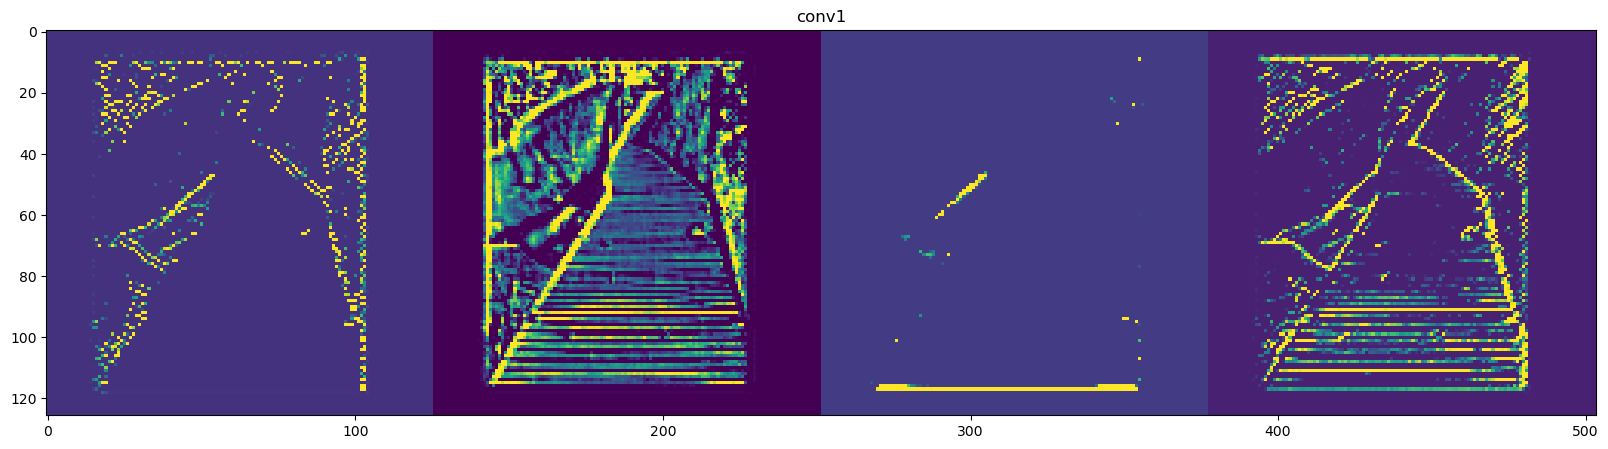

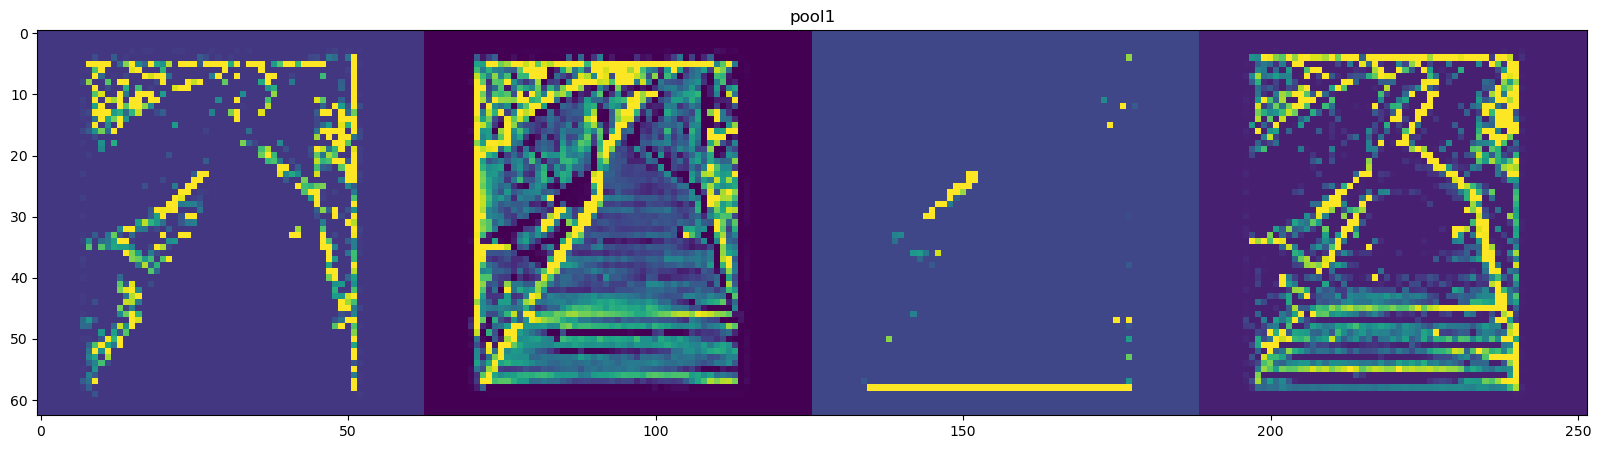

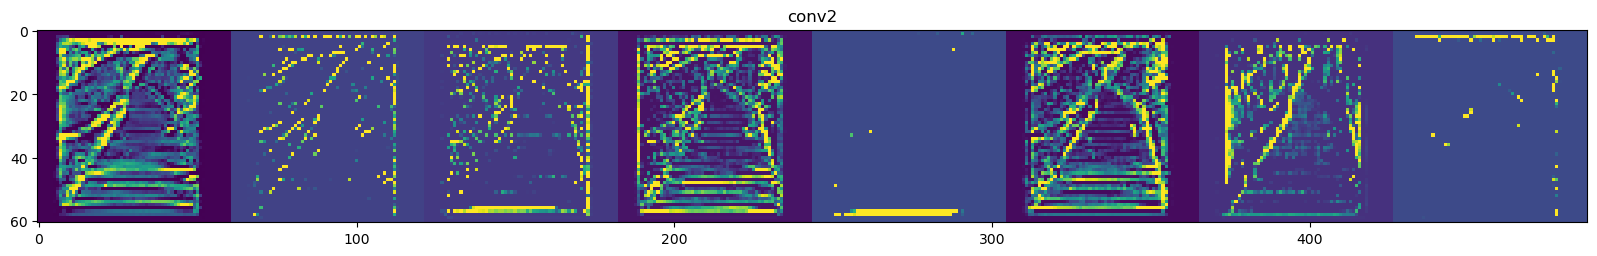

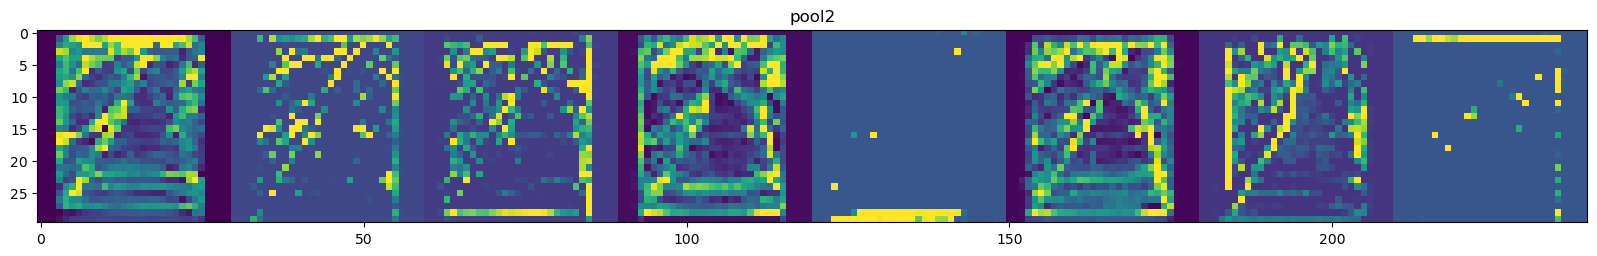

In [67]:

# 모델 호출 (입력 데이터 제공)
_ = model(processed_image)  # 모델을 직접 호출하여 입력 형태 정의

# 이미지 예측 (특징 추출) - 각 레이어의 출력을 추출
layer_outputs = [layer.output for layer in model.layers]
activations = []

x = processed_image
for layer in model.layers:
    x = layer(x)
    activations.append(x)

# 각 레이어의 출력 (특징 맵) 시각화
layer_names = [layer.name for layer in model.layers]

for layer_name, layer_activation in zip(layer_names, activations):
    layer_activation = layer_activation.numpy()  # EagerTensor를 NumPy 배열로 변환
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    display_grid = np.zeros((size, size * n_features))
    
    for i in range(n_features):
        x = layer_activation[0, :, :, i]
        x -= np.mean(x)
        x /= (np.std(x) + 1e-5)  # 분모가 0이 되는 것을 방지하기 위해 작은 값을 더합니다.
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = x
    
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()

In [ ]:
## 전체 소스

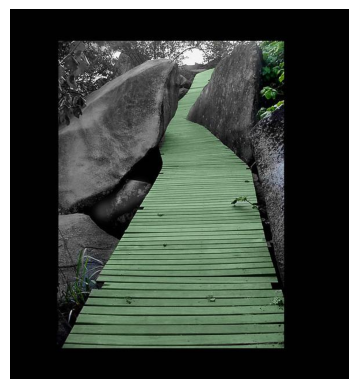

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 254, 254, 4)    │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 127, 127, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 125, 125, 8)    │           296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 62, 62, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 408 (1.59 KB)

 Trainable params: 408 (1.59 KB)

 Non-trainable params: 0 (0.00 B)

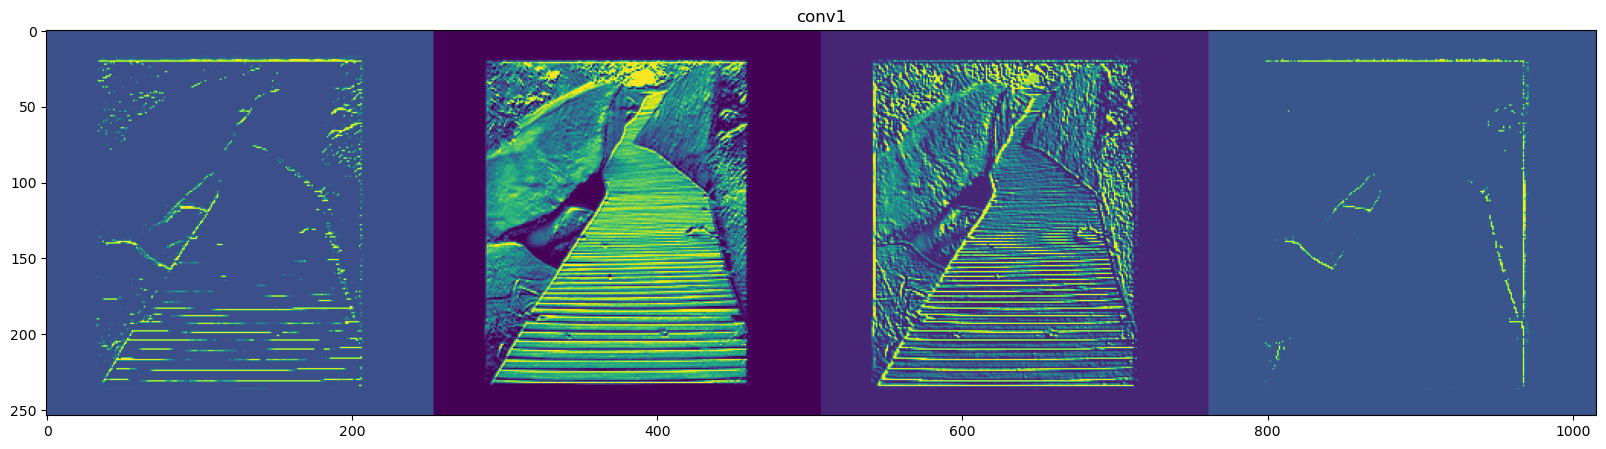

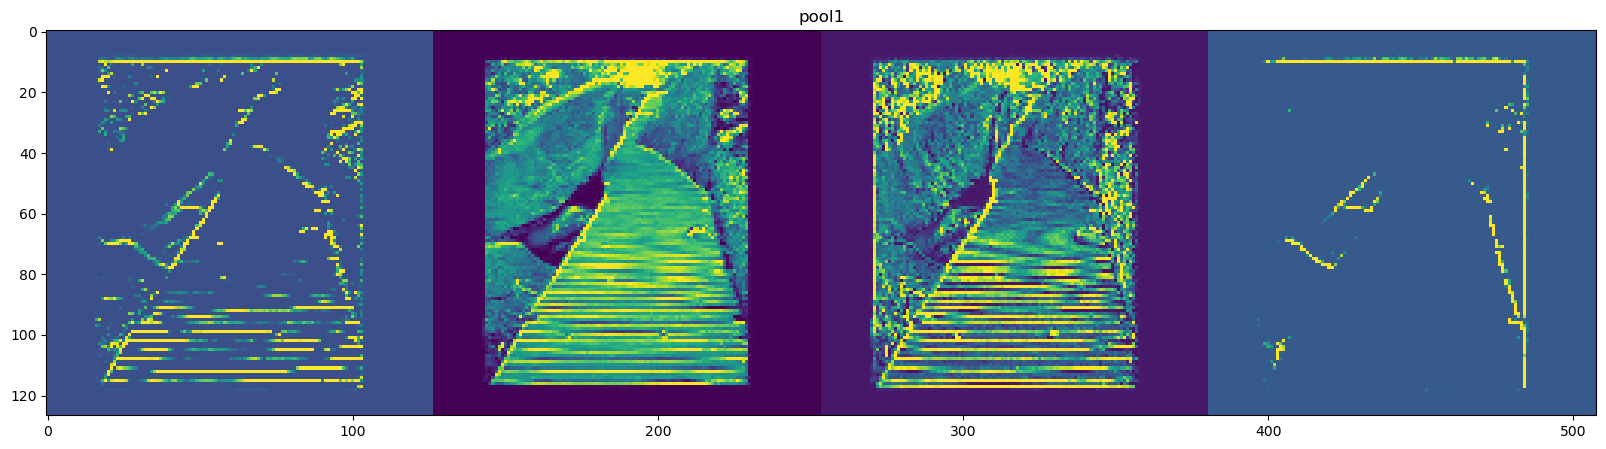

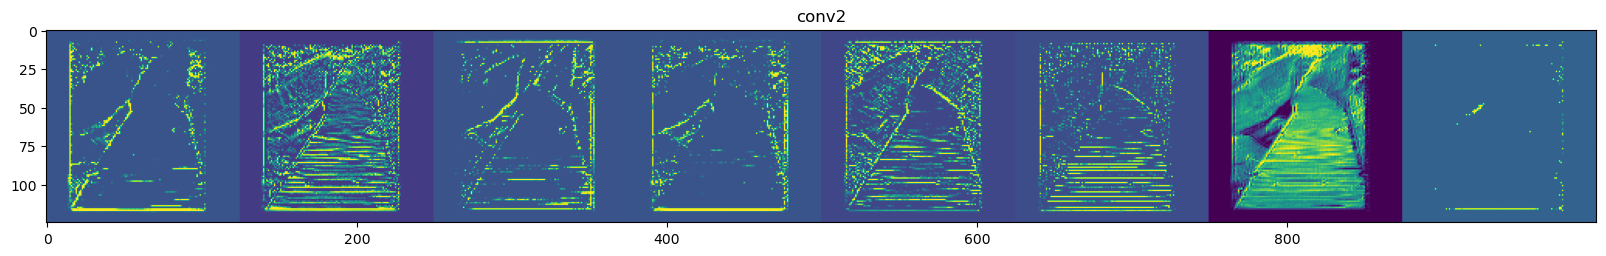

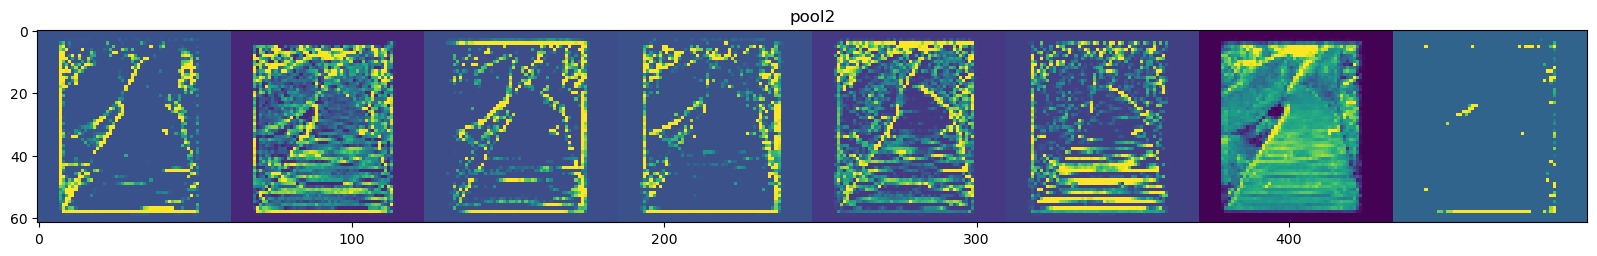

In [64]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 환경 변수 설정 (필요한 경우에만 사용)
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# 풍경 이미지 경로
image_path = '/Users/bumsuklee/PhpstormProjects/20240418-git-test-prototype-cms/llm-server/llm_server/image/nature_photos/00000429_(4).jpg'

# 이미지 로드 및 전처리 함수
def preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((256, 256))  # 모델 입력 크기로 리사이즈
    image_array = np.array(image) / 255.0  # 정규화
    image_array = image_array.reshape((1, 256, 256, 3))  # 모델 입력 형태로 변환
    return image_array

# 이미지 전처리
processed_image = preprocess_image(image_path)

# 이미지 표시
plt.imshow(Image.open(image_path))
plt.axis('off')
plt.show()

# CNN 모델 구성
model = models.Sequential([
    layers.Conv2D(4, (3, 3), activation='relu', input_shape=(256, 256, 3), name='conv1'),
    layers.MaxPooling2D((2, 2), name='pool1'),
    layers.Conv2D(8, (3, 3), activation='relu', name='conv2'),
    layers.MaxPooling2D((2, 2), name='pool2'),
])

# 모델 요약 출력
model.summary()

# 모델 호출 (입력 데이터 제공)
_ = model(processed_image)  # 모델을 직접 호출하여 입력 형태 정의

# 모델 호출 (입력 데이터 제공)
model.build((None, 256, 256, 3))  # 모델의 입력 형태를 정의합니다.
model.call(tf.constant(processed_image))

# 이미지 예측 (특징 추출) - 각 레이어의 출력을 추출
layer_outputs = [layer.output for layer in model.layers]
activations = []

x = processed_image
for layer in model.layers:
    x = layer(x)
    activations.append(x)

# 각 레이어의 출력 (특징 맵) 시각화
layer_names = [layer.name for layer in model.layers]

for layer_name, layer_activation in zip(layer_names, activations):
    layer_activation = layer_activation.numpy()  # EagerTensor를 NumPy 배열로 변환
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    display_grid = np.zeros((size, size * n_features))
    
    for i in range(n_features):
        x = layer_activation[0, :, :, i]
        x -= np.mean(x)
        x /= (np.std(x) + 1e-5)  # 분모가 0이 되는 것을 방지하기 위해 작은 값을 더합니다.
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = x
    
    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()